In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupShuffleSplit, GroupKFold
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve,
)
from sklearn.calibration import calibration_curve
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from pathlib import Path
import subprocess
import sys

REPO_URL = "https://github.com/bahaa1515/EECE-693-project.git"
COLAB_REPO_DIR = Path("/content/EECE-693-project")

def find_project_root() -> Path:
    for candidate in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
        if (candidate / "src" / "config.py").exists():
            return candidate
    if COLAB_REPO_DIR.exists() and (COLAB_REPO_DIR / "src" / "config.py").exists():
        return COLAB_REPO_DIR
    try:
        import google.colab  # type: ignore  # noqa: F401
    except ImportError as exc:
        raise FileNotFoundError(
            "Could not find the project root. Run this notebook from the repo root, "
            "from the notebooks folder, or clone the repo in Colab first."
        ) from exc
    subprocess.run(["git", "clone", REPO_URL, str(COLAB_REPO_DIR)], check=True)
    return COLAB_REPO_DIR

PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
print(f"Project root: {PROJECT_ROOT}")

from src.config import DATA_PROCESSED, OUTPUT_TABLES, OUTPUT_FIGURES

try:
    from xgboost import XGBClassifier
    HAS_XGB = True
    print("XGBoost available")
except ImportError:
    HAS_XGB = False
    print("XGBoost not installed - skipping")


In [2]:
labeled_path = DATA_PROCESSED / "baseline_smartwatch_features_labeled.parquet"
df = pd.read_parquet(labeled_path)

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
print("Users:", df["user_key"].nunique())

df.head()

Shape: (31125, 47)
Columns: ['user_key', 'anchor_relative_minute', 'window_start_minute', 'window_end_minute', 'observed_minutes', 'coverage', 'n_rows_in_window', 'hr_mean', 'hr_std', 'hr_min', 'hr_max', 'hr_median', 'hr_missing_pct', 'steps_sum', 'steps_mean', 'steps_max', 'intensity_mean', 'intensity_std', 'intensity_max', 'active_minute_frac', 'activity_frac_walk', 'activity_frac_running', 'activity_frac_activity_high', 'activity_frac_sedentary', 'activity_frac_sleep', 'activity_frac_not_worn', 'activity_frac_charging', 'activity_frac_unknown', 'day_hr_mean', 'night_hr_mean', 'day_steps_sum', 'night_steps_sum', 'day_active_frac', 'night_active_frac', 'hr_slope', 'steps_slope', 'questionnaire_relative_minute', 'target_binary', 'week_end_day', 'questionnaire_day', 'doc_flag', 'hospital_flag', 'er_flag', 'oral_flag', 'symptom_flag', 'time_to_label_minutes', 'time_to_label_days']
Users: 18


,user_key,anchor_relative_minute,window_start_minute,window_end_minute,observed_minutes,coverage,n_rows_in_window,hr_mean,hr_std,hr_min,...,target_binary,week_end_day,questionnaire_day,doc_flag,hospital_flag,er_flag,oral_flag,symptom_flag,time_to_label_minutes,time_to_label_days
0,294,1440,0,1440,1355,0.940972,1355,69.599998,1.788854,68.0,...,1.0,0.0,1.0,False,False,False,False,True,0.0,0.000000
1,294,1500,60,1500,1295,0.899306,1295,69.599998,1.788854,68.0,...,1.0,7.0,8.0,False,False,False,False,True,10020.0,6.958333
2,294,1560,120,1560,1235,0.857639,1235,69.599998,1.788854,68.0,...,1.0,7.0,8.0,False,False,False,False,True,9960.0,6.916667
3,294,1620,180,1620,1175,0.815972,1175,69.599998,1.788854,68.0,...,1.0,7.0,8.0,False,False,False,False,True,9900.0,6.875000
4,294,1680,240,1680,1115,0.774306,1115,69.599998,1.788854,68.0,...,1.0,7.0,8.0,False,False,False,False,True,9840.0,6.833333


In [3]:
print("Target distribution:")
print(df["target_binary"].value_counts(dropna=False))
print()
print("Target normalized:")
print(df["target_binary"].value_counts(normalize=True, dropna=False))
print()

print("Missing values per column (%):")
display((df.isna().mean() * 100).sort_values(ascending=False).head(20))

print("\nRows per user:")
display(df["user_key"].value_counts().sort_values().head(10))
display(df["user_key"].value_counts().sort_values(ascending=False).head(10))

Target distribution:
target_binary
0.0    21701
1.0     9424
Name: count, dtype: int64

Target normalized:
target_binary
0.0    0.697221
1.0    0.302779
Name: proportion, dtype: float64

Missing values per column (%):


night_hr_mean             6.489960
hr_slope                  2.123695
hr_std                    2.123695
day_hr_mean               1.946988
hr_max                    1.767068
hr_mean                   1.767068
hr_min                    1.767068
hr_median                 1.767068
n_rows_in_window          0.000000
observed_minutes          0.000000
window_end_minute         0.000000
window_start_minute       0.000000
coverage                  0.000000
anchor_relative_minute    0.000000
user_key                  0.000000
steps_mean                0.000000
steps_sum                 0.000000
hr_missing_pct            0.000000
steps_max                 0.000000
active_minute_frac        0.000000
dtype: float64


Rows per user:


user_key
278      96
328     126
454     145
917     504
398     688
625     798
764     839
808    1141
473    1177
514    1711
Name: count, dtype: int64

user_key
113    3707
294    3582
343    3178
702    3092
939    2955
190    2927
701    2455
447    2004
514    1711
473    1177
Name: count, dtype: int64

In [4]:
feature_cols = [
    "observed_minutes",
    "coverage",
    "n_rows_in_window",

    "hr_mean",
    "hr_std",
    "hr_min",
    "hr_max",
    "hr_median",
    "hr_missing_pct",

    "steps_sum",
    "steps_mean",
    "steps_max",

    "intensity_mean",
    "intensity_std",
    "intensity_max",

    "active_minute_frac",

    "activity_frac_walk",
    "activity_frac_running",
    "activity_frac_activity_high",
    "activity_frac_sedentary",
    "activity_frac_sleep",
    "activity_frac_not_worn",
    "activity_frac_charging",
    "activity_frac_unknown",

    "day_hr_mean",
    "night_hr_mean",
    "day_steps_sum",
    "night_steps_sum",
    "day_active_frac",
    "night_active_frac",

    "hr_slope",
    "steps_slope",
]

In [5]:
missing_features = [c for c in feature_cols if c not in df.columns]
print("Missing feature columns:", missing_features)
print("Number of selected features:", len(feature_cols))

Missing feature columns: []
Number of selected features: 32


In [6]:
X = df[feature_cols].copy()
y = df["target_binary"].astype(int).copy()
groups = df["user_key"].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Unique users:", groups.nunique())

X shape: (31125, 32)
y shape: (31125,)
Unique users: 18


In [7]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)

train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train = X.iloc[train_idx].copy()
X_test = X.iloc[test_idx].copy()

y_train = y.iloc[train_idx].copy()
y_test = y.iloc[test_idx].copy()

groups_train = groups.iloc[train_idx].copy()
groups_test = groups.iloc[test_idx].copy()

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print()

print("Train users:", groups_train.nunique(), sorted(groups_train.unique()))
print("Test users:", groups_test.nunique(), sorted(groups_test.unique()))
print()

print("Overlap in users:", set(groups_train.unique()) & set(groups_test.unique()))
print()

print("Train target distribution:")
print(y_train.value_counts(normalize=True))
print()

print("Test target distribution:")
print(y_test.value_counts(normalize=True))

Train shape: (17586, 32)
Test shape: (13539, 32)

Train users: 13 [np.int64(278), np.int64(328), np.int64(398), np.int64(447), np.int64(473), np.int64(514), np.int64(625), np.int64(701), np.int64(702), np.int64(764), np.int64(808), np.int64(917), np.int64(939)]
Test users: 5 [np.int64(113), np.int64(190), np.int64(294), np.int64(343), np.int64(454)]

Overlap in users: set()

Train target distribution:
target_binary
0    0.835494
1    0.164506
Name: proportion, dtype: float64

Test target distribution:
target_binary
0    0.517616
1    0.482384
Name: proportion, dtype: float64


In [8]:
majority_class = y_train.mode()[0]
baseline_pred = np.full(len(y_test), majority_class)

print("Majority class in training:", majority_class)
print("Baseline accuracy:", accuracy_score(y_test, baseline_pred))
print("Baseline precision:", precision_score(y_test, baseline_pred, zero_division=0))
print("Baseline recall:", recall_score(y_test, baseline_pred, zero_division=0))
print("Baseline F1:", f1_score(y_test, baseline_pred, zero_division=0))

Majority class in training: 0
Baseline accuracy: 0.517615776645247
Baseline precision: 0.0
Baseline recall: 0.0
Baseline F1: 0.0


In [9]:
def evaluate_model(name, model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
    else:
        y_score = None

    results = {
        "model": name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
    }

    if y_score is not None:
        results["roc_auc"] = roc_auc_score(y_test, y_score)
        results["pr_auc"] = average_precision_score(y_test, y_score)
        results["brier"] = brier_score_loss(y_test, y_score)
    else:
        results["roc_auc"] = np.nan
        results["pr_auc"] = np.nan
        results["brier"] = np.nan

    print(f"\n===== {name} =====")
    print("Confusion matrix:")
    print(confusion_matrix(y_test, y_pred))
    print()
    print(classification_report(y_test, y_pred, zero_division=0))

    return results, y_pred, y_score

In [10]:
logreg_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=42
    ))
])

logreg_results, logreg_pred, logreg_score = evaluate_model(
    "Logistic Regression",
    logreg_model,
    X_train, y_train,
    X_test, y_test
)


===== Logistic Regression =====
Confusion matrix:
[[3505 3503]
 [2690 3841]]

              precision    recall  f1-score   support

           0       0.57      0.50      0.53      7008
           1       0.52      0.59      0.55      6531

    accuracy                           0.54     13539
   macro avg       0.54      0.54      0.54     13539
weighted avg       0.55      0.54      0.54     13539



In [ ]:
rf_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("clf", RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        min_samples_split=20,
        min_samples_leaf=10,
        class_weight="balanced",
        random_state=42,
        n_jobs=1
    ))
])

rf_results, rf_pred, rf_score = evaluate_model(
    "Random Forest",
    rf_model,
    X_train, y_train,
    X_test, y_test
)


In [12]:
# ── XGBoost ──────────────────────────────────────────────────────────────
if HAS_XGB:
    neg_count = (y_train == 0).sum()
    pos_count = (y_train == 1).sum()
    spw = neg_count / pos_count

    xgb_model = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("clf", XGBClassifier(
            n_estimators=200,
            max_depth=5,
            learning_rate=0.1,
            scale_pos_weight=spw,
            random_state=42,
            eval_metric="logloss",
            use_label_encoder=False,
        ))
    ])

    xgb_results, xgb_pred, xgb_score = evaluate_model(
        "XGBoost", xgb_model,
        X_train, y_train, X_test, y_test
    )
else:
    xgb_results, xgb_pred, xgb_score = None, None, None

/home/mouradox/Downloads/693-project-baseline/.venv/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [19:55:12] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



===== XGBoost =====
Confusion matrix:
[[6623  385]
 [4867 1664]]

              precision    recall  f1-score   support

           0       0.58      0.95      0.72      7008
           1       0.81      0.25      0.39      6531

    accuracy                           0.61     13539
   macro avg       0.69      0.60      0.55     13539
weighted avg       0.69      0.61      0.56     13539



In [13]:
all_results = [logreg_results, rf_results]
if xgb_results is not None:
    all_results.append(xgb_results)
results_df = pd.DataFrame(all_results).sort_values("f1", ascending=False)
results_df

,model,accuracy,precision,recall,f1,roc_auc,pr_auc,brier
0,Logistic Regression,0.542581,0.523012,0.588118,0.553658,0.577994,0.658248,0.312919
1,Random Forest,0.678411,0.854214,0.401929,0.546647,0.632850,0.724310,0.253877
2,XGBoost,0.612084,0.812103,0.254785,0.387879,0.581072,0.653635,0.312109


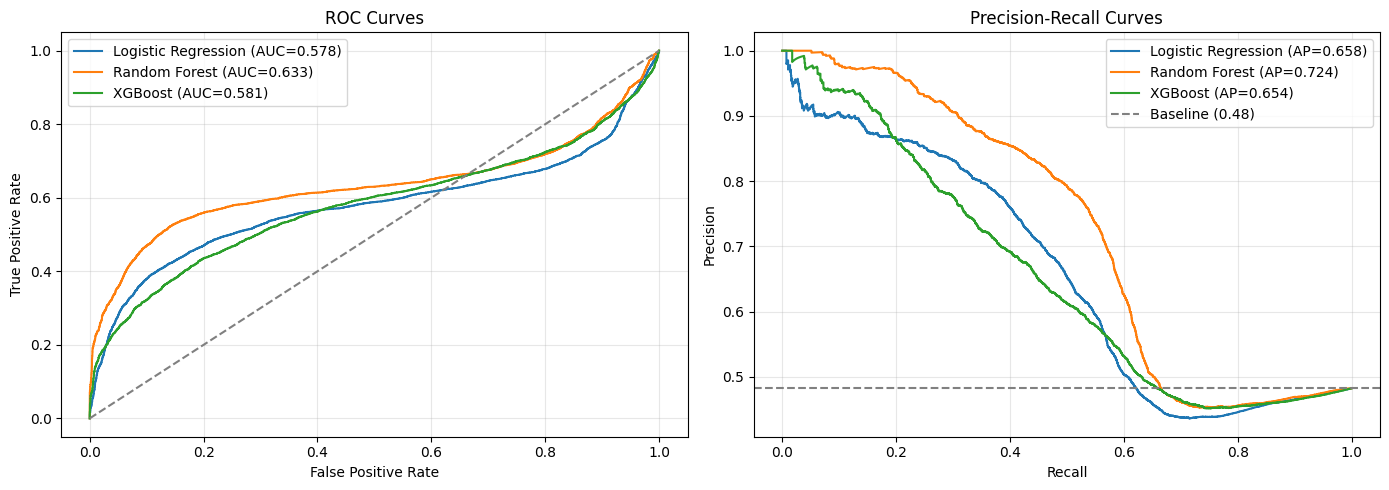

In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

models_info = [
    ("Logistic Regression", logreg_score),
    ("Random Forest",       rf_score),
]
if xgb_score is not None:
    models_info.append(("XGBoost", xgb_score))

# ── ROC curves ──
for name, scores in models_info:
    if scores is not None:
        fpr, tpr, _ = roc_curve(y_test, scores)
        auc_val = roc_auc_score(y_test, scores)
        ax1.plot(fpr, tpr, label=f"{name} (AUC={auc_val:.3f})")
ax1.plot([0, 1], [0, 1], linestyle="--", color="gray")
ax1.set_xlabel("False Positive Rate")
ax1.set_ylabel("True Positive Rate")
ax1.set_title("ROC Curves")
ax1.legend()
ax1.grid(True, alpha=0.3)

# ── Precision-Recall curves ──
baseline_pr = y_test.mean()
for name, scores in models_info:
    if scores is not None:
        prec, rec, _ = precision_recall_curve(y_test, scores)
        ap_val = average_precision_score(y_test, scores)
        ax2.plot(rec, prec, label=f"{name} (AP={ap_val:.3f})")
ax2.axhline(y=baseline_pr, linestyle="--", color="gray", label=f"Baseline ({baseline_pr:.2f})")
ax2.set_xlabel("Recall")
ax2.set_ylabel("Precision")
ax2.set_title("Precision-Recall Curves")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_FIGURES / "roc_pr_curves.png", dpi=150, bbox_inches="tight")
plt.show()

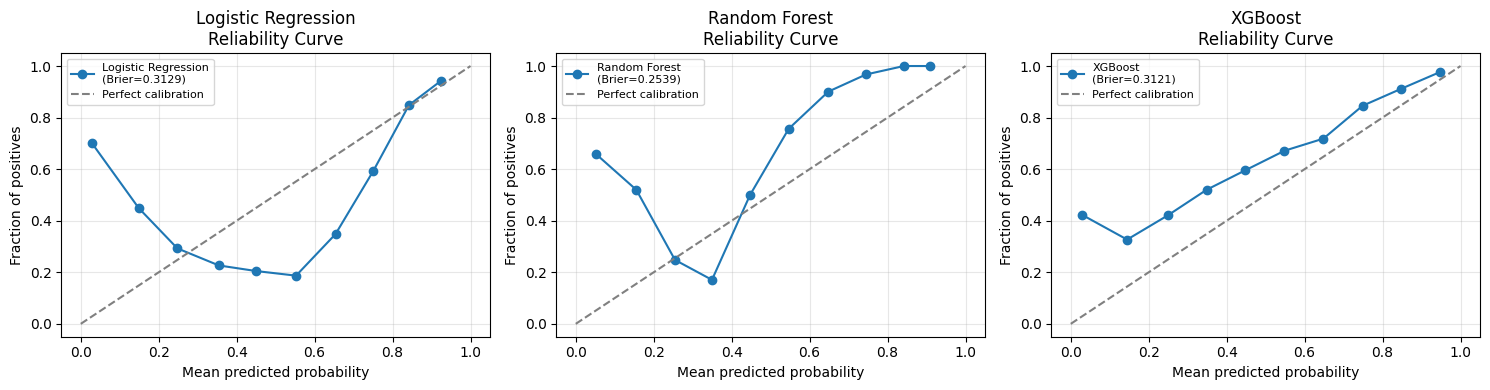

Points on the diagonal = well-calibrated.
Above diagonal = under-confident. Below = over-confident.


In [15]:
# ── Calibration / Reliability curves ──────────────────────────────────────
fig, axes = plt.subplots(1, len(models_info), figsize=(5*len(models_info), 4))
if len(models_info) == 1:
    axes = [axes]

for ax, (name, scores) in zip(axes, models_info):
    if scores is not None:
        brier = brier_score_loss(y_test, scores)
        prob_true, prob_pred = calibration_curve(y_test, scores, n_bins=10)
        ax.plot(prob_pred, prob_true, "o-", label=f"{name}\n(Brier={brier:.4f})")
        ax.plot([0, 1], [0, 1], "--", color="gray", label="Perfect calibration")
        ax.set_xlabel("Mean predicted probability")
        ax.set_ylabel("Fraction of positives")
        ax.set_title(f"{name}\nReliability Curve")
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_FIGURES / "calibration_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Points on the diagonal = well-calibrated.")
print("Above diagonal = under-confident. Below = over-confident.")

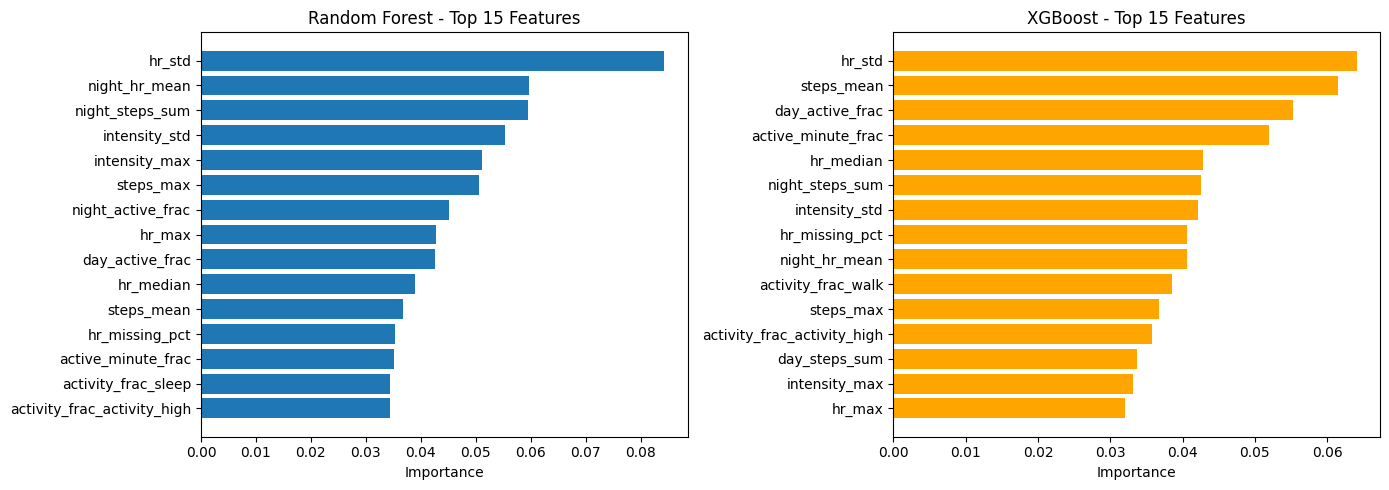

In [16]:
# ── Feature importances (RF and XGBoost) ──────────────────────────────────
n_plots = 1 + (1 if HAS_XGB else 0)
fig, axes = plt.subplots(1, n_plots, figsize=(7*n_plots, 5))
if n_plots == 1:
    axes = [axes]

rf_imp = pd.Series(rf_model.named_steps["clf"].feature_importances_, index=feature_cols).sort_values(ascending=False)
axes[0].barh(rf_imp.head(15).index[::-1], rf_imp.head(15).values[::-1])
axes[0].set_xlabel("Importance")
axes[0].set_title("Random Forest - Top 15 Features")

if HAS_XGB and xgb_model is not None:
    xgb_imp = pd.Series(xgb_model.named_steps["clf"].feature_importances_, index=feature_cols).sort_values(ascending=False)
    axes[1].barh(xgb_imp.head(15).index[::-1], xgb_imp.head(15).values[::-1], color="orange")
    axes[1].set_xlabel("Importance")
    axes[1].set_title("XGBoost - Top 15 Features")

plt.tight_layout()
plt.savefig(OUTPUT_FIGURES / "feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# ── 5-fold GroupKFold Cross-Validation ────────────────────────────────────
# User-stratified CV: no user appears in both train and test within a fold.

gkf = GroupKFold(n_splits=5)

def run_cv(name, make_model):
    """Run GroupKFold CV for a single model, return per-fold metrics."""
    rows = []
    for fold, (tr_idx, te_idx) in enumerate(gkf.split(X, y, groups=groups)):
        X_tr, X_te = X.iloc[tr_idx], X.iloc[te_idx]
        y_tr, y_te = y.iloc[tr_idx], y.iloc[te_idx]

        model = make_model(y_tr)
        model.fit(X_tr, y_tr)
        y_pred = model.predict(X_te)
        y_proba = model.predict_proba(X_te)[:, 1] if hasattr(model, "predict_proba") else None

        row = {
            "model": name, "fold": fold,
            "accuracy": accuracy_score(y_te, y_pred),
            "precision": precision_score(y_te, y_pred, zero_division=0),
            "recall": recall_score(y_te, y_pred, zero_division=0),
            "f1": f1_score(y_te, y_pred, zero_division=0),
        }
        if y_proba is not None:
            row["roc_auc"] = roc_auc_score(y_te, y_proba)
            row["pr_auc"] = average_precision_score(y_te, y_proba)
            row["brier"] = brier_score_loss(y_te, y_proba)
        rows.append(row)
        print(f"  Fold {fold}: F1={row['f1']:.4f}, AUC={row.get('roc_auc', float('nan')):.4f}")
    return pd.DataFrame(rows)

# LogReg CV
print("Logistic Regression CV:")
cv_logreg = run_cv("Logistic Regression", lambda y_tr: Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42))
]))

# RF CV
print("\nRandom Forest CV:")
cv_rf = run_cv("Random Forest", lambda y_tr: Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("clf", RandomForestClassifier(n_estimators=200, max_depth=10, min_samples_split=20,
                                    min_samples_leaf=10, class_weight="balanced",
                                    random_state=42, n_jobs=1))
]))

# XGBoost CV
if HAS_XGB:
    print("\nXGBoost CV:")
    def make_xgb(y_tr):
        spw = (y_tr == 0).sum() / max((y_tr == 1).sum(), 1)
        return Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("clf", XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.1,
                                   scale_pos_weight=spw, random_state=42,
                                   eval_metric="logloss", use_label_encoder=False))
        ])
    cv_xgb = run_cv("XGBoost", make_xgb)

# Combine and summarize
cv_all = pd.concat([cv_logreg, cv_rf] + ([cv_xgb] if HAS_XGB else []), ignore_index=True)

print("\n" + "=" * 60)
print("CROSS-VALIDATION SUMMARY (5-fold GroupKFold)")
print("=" * 60)
for name in cv_all["model"].unique():
    sub = cv_all[cv_all["model"] == name]
    print(f"\n  {name}:")
    for metric in ["accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc", "brier"]:
        if metric in sub.columns:
            print(f"    {metric:12s}: {sub[metric].mean():.4f} +/- {sub[metric].std():.4f}")


In [18]:
# ── Save all results ─────────────────────────────────────────────────────
results_df.to_csv(OUTPUT_TABLES / "baseline_model_results.csv", index=False)
cv_all.to_csv(OUTPUT_TABLES / "cv_summary.csv", index=False)
rf_imp.reset_index().rename(columns={"index": "feature", 0: "importance"}).to_csv(
    OUTPUT_TABLES / "random_forest_feature_importance.csv", index=False)
if HAS_XGB:
    xgb_imp.reset_index().rename(columns={"index": "feature", 0: "importance"}).to_csv(
        OUTPUT_TABLES / "xgboost_feature_importance.csv", index=False)

print("Saved to outputs/tables/:")
print("  - baseline_model_results.csv")
print("  - cv_summary.csv")
print("  - random_forest_feature_importance.csv")
if HAS_XGB:
    print("  - xgboost_feature_importance.csv")

print("\nSaved to outputs/figures/:")
print("  - roc_pr_curves.png")
print("  - calibration_curves.png")
print("  - feature_importance.png")

# ── Final Summary ──
print("\n" + "=" * 60)
print("COMPLETE BASELINE SUMMARY")
print("=" * 60)
print(f"\nDataset: {len(df)} samples, {df['user_key'].nunique()} users, {len(feature_cols)} features")
print(f"Positive rate: {y.mean()*100:.1f}%")
print(f"Split: 75/25 user-stratified (train={len(X_train)}, test={len(X_test)})")

print("\n-- Single-split results --")
for _, r in results_df.iterrows():
    print(f"  {r['model']:25s} | F1={r['f1']:.3f} | AUC={r['roc_auc']:.3f} | Brier={r['brier']:.4f}")

print("\n-- 5-fold GroupKFold CV --")
for name in cv_all["model"].unique():
    sub = cv_all[cv_all["model"] == name]
    print(f"  {name:25s} | F1={sub['f1'].mean():.3f}+/-{sub['f1'].std():.3f} "
          f"| AUC={sub['roc_auc'].mean():.3f}+/-{sub['roc_auc'].std():.3f}")

Saved to outputs/tables/:
  - baseline_model_results.csv
  - cv_summary.csv
  - random_forest_feature_importance.csv
  - xgboost_feature_importance.csv

Saved to outputs/figures/:
  - roc_pr_curves.png
  - calibration_curves.png
  - feature_importance.png

COMPLETE BASELINE SUMMARY

Dataset: 31125 samples, 18 users, 32 features
Positive rate: 30.3%
Split: 75/25 user-stratified (train=17586, test=13539)

-- Single-split results --
  Logistic Regression       | F1=0.554 | AUC=0.578 | Brier=0.3129
  Random Forest             | F1=0.547 | AUC=0.633 | Brier=0.2539
  XGBoost                   | F1=0.388 | AUC=0.581 | Brier=0.3121

-- 5-fold GroupKFold CV --
  Logistic Regression       | F1=0.298+/-0.235 | AUC=0.543+/-0.201
  Random Forest             | F1=0.253+/-0.343 | AUC=0.611+/-0.226
  XGBoost                   | F1=0.269+/-0.241 | AUC=0.575+/-0.214
